In [10]:
from Shared.shared import *
# from shared.shared_functions import *
# from project_imports.imports_primordial_fluctuations import *
from Shared.specific_CNB_sim import *

fig_dir = 'figures_local/neutrino_plots/'

# Functions.

## Work in Progress.

In [11]:
def compute_distances_velocity_filter(vectors, nu_mass):
    """
    Compute the Euclidean distances traveled by particles from the origin based on a momentum filter.
    """
    # Extract velocities and positions
    velocities = vectors[:, -1, 3:6]*kpc/s
    final_positions = vectors[:, -1, 0:3]*kpc
    
    # Convert velocities to momentum
    momentum = velocities * nu_mass
    
    # Calculate momentum magnitude for each particle
    mags = np.linalg.norm(momentum, axis=1)
    
    # Filter based on momentum values
    mask = (mags >= 0.01*Params.T_CNB) & (mags <= 10*Params.T_CNB)
    
    # Select particles based on the mask
    filtered_positions = final_positions[mask]
    
    # Compute the distances for the filtered particles
    distances = np.linalg.norm(filtered_positions, axis=1)

    print(f"{len(distances)} neutrinos selected.")

    return distances/kpc, mask


def compute_distances_cube_filter(vectors, lim):
    """
    Compute the Euclidean distances traveled by particles up to cube length.
    """
    # Extract positions
    coords = vectors[:, -1, 0:3]*kpc
    
    mask = (np.abs(coords[:,0]) <= lim) & \
           (np.abs(coords[:,1]) <= lim) & \
           (np.abs(coords[:,2]) <= lim)

    # Select particles inside cube
    inside_cube_coords = coords[mask]

    # Compute the distances for the filtered particles
    distances = np.linalg.norm(inside_cube_coords, axis=-1)

    print(f"{len(distances)} neutrinos selected.")

    return distances/kpc, mask


def compute_statistics(distances):
    """
    Compute and return statistical measures.
    """
    mean_distance = np.mean(distances)
    median_distance = np.median(distances)
    std_dev = np.std(distances)
    q25 = np.percentile(distances, 25)
    q75 = np.percentile(distances, 75)
    q95 = np.percentile(distances, 85)
    
    return mean_distance, median_distance, std_dev, q25, q75, q95


def PLOT_histograms_2x2(arrayA, arrayB):
    """Plot histograms of velocity magnitudes for the two arrays in a 2x2 layout with individual logarithmic bins."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    
    # Computing velocity magnitudes
    magsA = UTIL_magnitudes(arrayA)
    magsB = UTIL_magnitudes(arrayB)
    
    speed_of_light = 299792458
    magsA *= (kpc/s)/(m/s)/speed_of_light*100
    magsB *= (kpc/s)/(m/s)/speed_of_light*100

    # Generating separate logarithmically spaced bins for each distribution
    bin_num = 50
    log_bins_A_start = np.logspace(
        np.log10(np.min(magsA[:, 0])), np.log10(np.max(magsA[:, 0])), bin_num)
    log_bins_A_end = np.logspace(
        np.log10(np.min(magsA[:, 1])), np.log10(np.max(magsA[:, 1])), bin_num)
    log_bins_B_start = np.logspace(
        np.log10(np.min(magsB[:, 0])), np.log10(np.max(magsB[:, 0])), bin_num)
    log_bins_B_end = np.logspace(
        np.log10(np.min(magsB[:, 1])), np.log10(np.max(magsB[:, 1])), bin_num)

    # Plotting histogram for "Our Vectors" - Start
    axes[0, 0].hist(magsA[:, 0], bins=log_bins_A_start, alpha=0.5, color="blue")
    axes[0, 0].set_title("Our Vectors - Start")
    axes[0, 0].set_xlabel(r"Velocity Magnitude [$\%$ of c]")
    axes[0, 0].set_ylabel("Particle Count")
    axes[0, 0].set_xscale("log")

    # Plotting histogram for "Our Vectors" - End
    axes[0, 1].hist(magsA[:, 1], bins=log_bins_A_end, alpha=0.5, color="blue")
    axes[0, 1].set_title("Our Vectors - End")
    axes[0, 1].set_xlabel(r"Velocity Magnitude [$\%$ of c]")
    axes[0, 1].set_ylabel("Particle Count")
    axes[0, 1].set_xscale("log")

    # Plotting histogram for "Elbers Vectors" - Start
    axes[1, 0].hist(magsB[:, 0], bins=log_bins_B_start, alpha=0.5, color="red")
    axes[1, 0].set_title("Elbers Vectors - Start")
    axes[1, 0].set_xlabel(r"Velocity Magnitude [$\%$ of c]")
    axes[1, 0].set_ylabel("Particle Count")
    axes[1, 0].set_xscale("log")

    # Plotting histogram for "Elbers Vectors" - End
    axes[1, 1].hist(magsB[:, 1], bins=log_bins_B_end, alpha=0.5, color="red")
    axes[1, 1].set_title("Elbers Vectors - End")
    axes[1, 1].set_xlabel(r"Velocity Magnitude [$\%$ of c]")
    axes[1, 1].set_ylabel("Particle Count")
    axes[1, 1].set_xscale("log")

    plt.tight_layout()
    plt.show()
    plt.close()


def PLOT_mom_distr(velocities, nu_mass, most_likely=False):

    # Momentum parameters
    p_num, phis, thetas = 200, 20, 20
    p_start, p_stop = 0.01, 400

    # Convert velocities to momentum magnitudes
    momentum = velocities*(kpc/s) * nu_mass
    mags = np.linalg.norm(momentum, axis=-1)

    # Select
    p0, pBack = mags[...,0], mags[...,-1]
    y0 = p0/Params.T_CNB

    # Sort
    ind = p0.argsort(axis=-1)
    pBack = np.take_along_axis(pBack, ind, axis=-1)
    y0 = np.take_along_axis(y0, ind, axis=-1)

    if most_likely:
        # Select "most likely clustered" neutrinos of each velocity batch
        pBack_blocks = pBack.reshape((p_num, phis*thetas))
        pBack = np.min(pBack_blocks, axis=-1)
        y0_blocks = y0.reshape((p_num, phis*thetas))
        y0 = y0_blocks[...,0]

    # Fermi Dirac of the final momenta
    FDBack = CALC_Fermi_Dirac(pBack)

    # Figure setup
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111)
    ax.set_title(r'Momentum distribution, $m_\nu=$'+f'{nu_mass}')

    # Input velocites
    ax.loglog(
        y0, FDBack, label='Data', c='blue', ls='solid', alpha=0.9
    )

    # Fermi-Dirac distribution
    pOG = np.geomspace(p_start*Params.T_CNB, p_stop*Params.T_CNB, FDBack.shape[-1])
    FDvalsOG = CALC_Fermi_Dirac(pOG)
    yOG = pOG/Params.T_CNB
    ax.loglog(
        yOG, FDvalsOG, label='Fermi-Dirac', c='magenta', ls=':', alpha=0.9
    )

    # ax.set_ylim(1e-2, 1e0)
    # ax.set_xlim(p_start, 1e1)
    ax.set_ylim(1e-5, 1e0)
    ax.set_xlim(p_start, 1e2)
    plt.show()
    plt.close()


def PLOT_distances_to_CNB_LSS_gradient():
    p_low = 0.01 * Params.T_CNB
    p_med = CALC_mean_CNB_momentum()
    p_upp = 10 * Params.T_CNB

    array_len = 50
    m_range = np.logspace(-5, 0, array_len) * eV

    lower = np.array(
        [CALC_LSS_distance(Z_LSS_CNB, p_low, m_nu) for m_nu in m_range])
    mean = np.array(
        [CALC_LSS_distance(Z_LSS_CNB, p_med, m_nu) for m_nu in m_range])
    upper = np.array(
        [CALC_LSS_distance(Z_LSS_CNB, p_upp, m_nu) for m_nu in m_range])

    fig = plt.figure()
    ax = fig.add_subplot(111)

    dist_unit = Params.Mpc / Params.h

    # Create Y values for gradient
    y_values_lower = np.linspace(lower, mean, array_len, axis=-1)
    y_values_upper = np.linspace(mean, upper, array_len, axis=-1)

    # Create gradient based on distance from median
    gradient_lower = np.exp(-((y_values_lower - mean) ** 2) / (2 * ((upper - lower) / 1) ** 2))
    gradient_upper = np.exp(-((y_values_upper - mean) ** 2) / (2 * ((upper - lower) / 1) ** 2))

    # Create color map
    color_map = plt.cm.Blues

    # Plot lower gradient
    for i in range(array_len-1):
        plt.fill_between(m_range, y_values_lower[:, i] / dist_unit, y_values_lower[:, i + 1] / dist_unit,
                         color=color_map(gradient_lower[0, i]), alpha=0.7)

    # Plot upper gradient
    for i in range(array_len-1):
        plt.fill_between(m_range, y_values_upper[:, i] / dist_unit, y_values_upper[:, i + 1] / dist_unit,
                         color=color_map(gradient_upper[0, i]), alpha=0.7)

    ax.loglog(m_range, lower / dist_unit, color='red')
    ax.loglog(m_range, mean / dist_unit, color='red')
    ax.loglog(m_range, upper / dist_unit, color='red')
    ax.set_xlabel(r'$m_\nu$, [eV]')
    ax.set_ylabel('Distance to LSS [Mpc/h]')

    plt.show()
    plt.close()


# PLOT_distances_to_CNB_LSS_gradient()

# note: work in progress
# PLOT_mom_distr(Zimmer_vel, nu_mass=0.05*eV, most_likely=True)

## Data Selection.

In [12]:
def DATA_extract_batch_number(filename):
    """
    Extract batch number from the filename.
    """
    match = re.search(r"batch(\d+)", filename)
    if match:
        return int(match.group(1))
    return 0


def DATA_get_files_from_directory(directory_path, substring):
    """
    Return a list of filenames from the given directory that contain the given substring.
    Filenames are sorted based on the batch number.
    """
    all_files = os.listdir(directory_path)
    matching_files = [f for f in all_files if substring in f]

    # Sort based on the batch number
    matching_files.sort(key=DATA_extract_batch_number)

    return [os.path.join(directory_path, f) for f in matching_files]


def DATA_concatenate_npy_files(filenames):
    # Load arrays from each file
    arrays = [np.load(filename) for filename in filenames]
    
    # Concatenate arrays along the first axis
    result = np.concatenate(arrays, axis=0)
    
    return result


def DATA_positions(vectors):
    return vectors[...,:3]


def DATA_velocities(vectors):
    return vectors[...,3:]


## Utilities.

In [13]:
def UTIL_magnitudes(vectors):
    return np.linalg.norm(vectors, axis=-1)


def UTIL_select_neutrinos_momentum_filter(vectors, nu_mass):
    # Extract velocities and positions and attach units
    zBack_velocities = vectors[:, -1, 3:6]*Params.kpc/Params.s

    # note on selection
    # 52000 with z0 velocities (65% of neutrinos)
    # 65381 with zBack velocities (81% of neutrinos)

    # Convert velocities to momentum magnitudes
    momentum = zBack_velocities * nu_mass
    mags = UTIL_magnitudes(momentum)

    # Filter based on momentum values
    selection = (mags >= 0.01*Params.T_CNB) & (mags <= 10*Params.T_CNB)
    neutrinos = np.count_nonzero(selection)

    percent = neutrinos/len(vectors)*100
    print(f'{neutrinos} ({percent:.1f}%) neutrinos selected.')

    return vectors[selection]


def UTIL_generate_redshift_array(zBack, num_points):
    
    z_values = np.logspace(0, np.log10(zBack + 1), num_points) - 1
    z_values[-1] = zBack  # Ensure last value is exactly zBack

    return z_values


def UTIL_generate_redshift_array_interval(zA, zB, num_points):

    return np.logspace(np.log10(zA+1), np.log10(zB+1), num_points) - 1


## Calculations.

In [14]:
def CALC_Hubble_rate(z):
    # Hubble rate in "numerical" units.
    return Params.H0*np.sqrt(Params.Omega_R*(1+z)**4 + Params.Omega_M*(1+z)**3 + Params.Omega_L)


def CALC_Chi_integrand(z, p_0, m_nu):
    # Comoving distance integral for massive particles
    integrand = p_0/CALC_Hubble_rate(z)/np.sqrt(p_0**2 + m_nu**2/((1+z)**2))
    
    # Integrand is returned with preface units
    return integrand


def CALC_LSS_distance(z_LSS, p_0=1.0, m_nu=0.0):

    # Logarithmically spaced redshifts starting at zero, ending at z_LSS
    z_int_range = UTIL_generate_redshift_array(z_LSS, num_points=100)

    # Comoving distance (Chi) to last scattering surface (LSS)
    integrand = CALC_Chi_integrand(z_int_range, p_0, m_nu)
    Chi_LSS = np.trapz(integrand, x=z_int_range)

    return Chi_LSS


def CALC_mean_CNB_momentum():    

    # Integrals from d^3p to p^2 dp
    integrand_p = lambda p: p**3*CALC_Fermi_Dirac(p)
    norm = lambda p: p**2*CALC_Fermi_Dirac(p)

    p_min, p_max = 0.001*Params.T_CNB, 100*Params.T_CNB
    p_range = np.geomspace(p_min, p_max, 10_000)

    frac1 = np.trapz(integrand_p(p_range), p_range)
    frac2 = np.trapz(norm(p_range), p_range)

    return frac1/frac2


def CALC_CDF_Fermi_Dirac_normed(p, T, p_norm):
    CDF = p - T*np.log(np.exp(p/T)+1) + T*np.log(2)
    norm = p_norm - T*np.log(np.exp(p_norm/T)+1) + T*np.log(2)
    return CDF/norm


def CALC_sample_Fermi_Dirac_momentum(N, T, p_norm):
    p_samples = np.zeros(N)
    
    for i in range(N):
        u = np.random.uniform(0, 1)
        
        try:
            # Use Brent's method for root finding
            root = root_scalar(
                lambda p: CALC_CDF_Fermi_Dirac_normed(p, T, p_norm) - u, 
                bracket=[0.01 * T, p_norm], 
                method='brentq'
            )
            p_samples[i] = root.root
        except ValueError:
            # print(f"Skipped iteration {i} due to bracketing issues.")
            continue
    
    return p_samples


## Analysis and Plotting.

In [64]:
def PLOT_chi_integrand(z_end, z_steps, p_0, m_nu):

    # Logarithmically spaced redshifts starting at zero, ending at z_end
    z_int_range = UTIL_generate_redshift_array_interval(0, z_end, z_steps)

    # Comoving distance (Chi) integrand
    integrand = CALC_Chi_integrand(z_int_range, p_0, m_nu)

    # Plot settings
    fig, ax = plt.subplots()

    normed = integrand/np.max(integrand)
    ax.semilogx(1+z_int_range, normed)

    ax.set_ylabel('Comoving distance integrand (normalized)')
    ax.set_xlabel('Redshift 1+z')
    ax.invert_xaxis()

    plt.show()
    plt.close()


def PLOT_chi_vs_z(z_interval, z_steps, p_0, m_nu):

    # Logarithmically spaced redshifts starting at zero, ending at z_LSS
    z_for_Chis = UTIL_generate_redshift_array_interval(
        z_interval[0], z_interval[1], num_points=z_steps)

    Chis_Mpc_div_h = np.empty(z_steps)
    for i, z in enumerate(z_for_Chis):
        
        z_int_range = UTIL_generate_redshift_array_interval(
            z_interval[0], z, num_points=z_steps)

        # Comoving distance (Chi) integrand
        integrand = CALC_Chi_integrand(z_int_range, p_0, m_nu)

        # Chi integral and conversion to Mpc/h units, for current z
        Chi = np.trapz(integrand, x=z_int_range)
        Chis_Mpc_div_h[i] = np.abs(Chi/(Params.Mpc/Params.h))

    # Plot settings
    fig, ax = plt.subplots()

    ax.semilogx(1+z_for_Chis, Chis_Mpc_div_h)
    print(f'Comoving distance from {np.min(Chis_Mpc_div_h)} to {np.max(Chis_Mpc_div_h)}')

    ax.set_ylabel('Comoving distance [Mpc/h]')
    ax.set_xlabel('Redshift 1+z')
    ax.invert_xaxis()

    plt.show()
    plt.close()


def PLOT_3d_positions_sampled(positions, percentage):
    """
    Plot the 3D scatter plot of final positions, randomly sampling a given percentage of the data.
    The x, y, z labels are displayed in exponential form.
    """
    num_samples = int(positions.shape[0] * (percentage / 100))
    sampled_indices = np.random.choice(positions.shape[0], num_samples, replace=False)
    
    sampled_positions = positions[sampled_indices]
    
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Extracting final x, y, z positions from the sampled data
    x = sampled_positions[..., 0]
    y = sampled_positions[..., 1]
    z = sampled_positions[..., 2]
    
    ax.scatter(x, y, z, alpha=0.7, edgecolors="w", s=10)
    ax.set_title(f"Final Positions of {percentage}% Sampled Particles")
    ax.set_xlabel("X [kpc]")
    ax.set_ylabel("Y [kpc]")
    ax.set_zlabel("Z [kpc]")
    
    # Use a formatter to display axis tick labels in scientific notation
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3,4))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)
    ax.zaxis.set_major_formatter(formatter)

    plt.savefig(f'{fig_dir}/3d_positions_sampled.pdf', bbox_inches='tight')
    plt.show()
    plt.close()


def PLOT_distances_histogram_log_bins_abs(
        distances, Fermi_Dirac=None, CMB_LSS=False, ax_lims=None):
    """
    Plot a histogram of distances with logarithmically spaced bins.
    """

    # Avoiding zero distance for log scale
    distances_above0 = distances[distances > 0]

    # div_unit = 1e3/Params.h
    div_unit = 1e3

    # From kpc to Mpc
    distances_Mpc = distances_above0/div_unit

    # Generating logarithmically spaced bins
    log_bins = np.logspace(
        np.log10(np.min(distances_Mpc)), np.log10(np.max(distances_Mpc)), 100
    )
    
    fig = plt.figure()
    ax = fig.add_subplot(111)

    # Plot simulation distances
    ax.hist(
        distances_Mpc, bins=log_bins, 
        color='blue', label='with gravity (simulations)', alpha=0.6)

    # Plot Fermi-Dirac sampled momentum comoving distances
    if Fermi_Dirac is not None:
        Fermi_Dirac_Mpc = Fermi_Dirac/div_unit
        ax.hist(
            Fermi_Dirac_Mpc, bins=log_bins, 
            color='magenta', label='without gravity (analytical)', alpha=0.4)

    # Plot Distance to CMB LSS
    if CMB_LSS:
        z_end_sim = 4.0
        CMB_LSS_dist = CALC_LSS_distance(z_end_sim)/(Params.Mpc/Params.h)
        ax.axvline(CMB_LSS_dist, c='red', ls='dashed')

        # Compute geometric mean for y-position of text
        y_lower, y_upper = ax.get_ylim()
        # y_mid = np.sqrt(y_lower * y_upper)
        y_mid = (y_upper - y_lower)/2

        # Add rotated text
        ax.text(
            CMB_LSS_dist, y_mid, 'CMB LSS', color='red', 
            rotation=90, va='center', ha='right')

    ax.set_xscale('log')
    # ax.set_title("Distances at z=4 (Log Bins)")
    ax.set_xlabel("Distance [Mpc]")
    ax.set_ylabel("Number of Neutrinos")
    ax.legend(loc='upper left')

    if ax_lims is not None:
        ax.set_xlim(ax_lims[0], ax_lims[1])
        ax.set_ylim(ax_lims[2], ax_lims[3])

    plt.savefig(f'{fig_dir}/distances_histogram_log_bins.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

def PLOT_distances_histogram_log_bins_abs_Cgrad(
        positions, Fermi_Dirac=None, CMB_LSS=False, ax_lims=None):
    """
    Plot a histogram of distances with logarithmically spaced bins.
    Bins are colored based on the fraction of neutrinos with negative x coordinates.
    
    Parameters:
    positions: array of shape (N, 3) containing (x, y, z) coordinates
    Fermi_Dirac_positions: array of shape (M, 3) containing (x, y, z) coordinates for Fermi-Dirac case
    """

    # Calculate distances from positions
    distances = np.linalg.norm(positions, axis=1)
    
    # Avoiding zero distance for log scale
    mask_above0 = distances > 0
    distances_above0 = distances[mask_above0]
    positions_above0 = positions[mask_above0]

    # div_unit = 1e3/Params.h
    div_unit = 1e3

    # From kpc to Mpc
    distances_Mpc = distances_above0/div_unit

    # Generating logarithmically spaced bins
    log_bins = np.logspace(
        np.log10(np.min(distances_Mpc)), np.log10(np.max(distances_Mpc)), 100
    )
    
    fig = plt.figure()
    ax = fig.add_subplot(111)

    # Calculate histogram and get bin assignments
    counts_sim, bin_edges = np.histogram(distances_Mpc, bins=log_bins)
    bin_indices = np.digitize(distances_Mpc, log_bins) - 1
    
    # Calculate bin centers and widths for plotting
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = bin_edges[1:] - bin_edges[:-1]
    
    # Calculate x-direction sum for each bin and normalize for coloring
    bin_colors = []
    x_sums = []
    for i in range(len(counts_sim)):
        if counts_sim[i] > 0:
            # Find neutrinos in this bin
            mask_in_bin = bin_indices == i
            x_coords_in_bin = positions_above0[mask_in_bin, 0]
            
            # Sum x coordinates in this bin
            x_sum = np.sum(x_coords_in_bin)
            x_sums.append(x_sum)
        else:
            x_sums.append(0)
    
    # Normalize x_sums to [0, 1] for coloring (more negative = closer to 1)
    x_sums = np.array(x_sums)
    if len(x_sums[x_sums != 0]) > 0:
        min_x_sum = np.min(x_sums)
        max_x_sum = np.max(x_sums)
        if min_x_sum < max_x_sum:
            # Normalize so that most negative gets 1.0, most positive gets 0.0
            normalized_negativeness = (max_x_sum - x_sums) / (max_x_sum - min_x_sum)
        else:
            normalized_negativeness = np.zeros_like(x_sums)
    else:
        normalized_negativeness = np.zeros_like(x_sums)
    
    for negativeness in normalized_negativeness:
        # Create color based on negativeness (darker blue = more negative sum)
        base_blue = np.array([0.0, 0.8, 1.0])  # Light blue
        dark_blue = np.array([0.0, 0.0, 0.5])   # Dark blue
        color = base_blue + negativeness * (dark_blue - base_blue)
        bin_colors.append(color)
    
    # Plot simulation distances with colored bins
    ax.bar(bin_centers, counts_sim, width=bin_widths, 
           color=bin_colors, label='with gravity (simulations)', alpha=0.8)

    # Plot Fermi-Dirac sampled momentum comoving distances
    if Fermi_Dirac is not None:
        Fermi_Dirac_Mpc = Fermi_Dirac/div_unit
        ax.hist(
            Fermi_Dirac_Mpc, bins=log_bins, histtype="step",
            color='magenta', label='without gravity (analytical)', alpha=0.99)

    # Plot Distance to CMB LSS
    if CMB_LSS:
        z_end_sim = 4.0
        CMB_LSS_dist = CALC_LSS_distance(z_end_sim)/(Params.Mpc/Params.h)
        ax.axvline(CMB_LSS_dist, c='red', ls='dashed')

        # Compute geometric mean for y-position of text
        y_lower, y_upper = ax.get_ylim()
        # y_mid = np.sqrt(y_lower * y_upper)
        y_mid = (y_upper - y_lower)/2

        # Add rotated text
        ax.text(
            CMB_LSS_dist, y_mid, 'CMB LSS', color='red', 
            rotation=90, va='center', ha='right')

    ax.set_xscale('log')
    # ax.set_title("Distances at z=4 (Log Bins)")
    ax.set_xlabel("Distance [Mpc]")
    ax.set_ylabel("Number of Neutrinos")
    ax.legend(loc='upper left')

    if ax_lims is not None:
        ax.set_xlim(ax_lims[0], ax_lims[1])
        ax.set_ylim(ax_lims[2], ax_lims[3])

    plt.savefig(f'{fig_dir}/distances_histogram_log_bins.pdf', bbox_inches='tight')
    plt.show()
    plt.close()


def PLOT_distances_histogram_log_bins_perc(
        distances, Fermi_Dirac=None, CMB_LSS=False, ax_lims=None):
    """
    Plot a histogram of distances with logarithmically spaced bins.
    """

    # Avoiding zero distance for log scale
    distances_above0 = distances[distances > 0]

    # div_unit = 1e3/Params.h
    div_unit = 1e3

    # From kpc to Mpc
    distances_Mpc = distances_above0/div_unit

    # Generating logarithmically spaced bins
    log_bins = np.logspace(
        np.log10(np.min(distances_Mpc)), np.log10(np.max(distances_Mpc)), 100
    )
    
    fig = plt.figure()
    ax = fig.add_subplot(111)

    # Calculate weights for percentage normalization
    weights_sim = np.ones(len(distances_Mpc)) / len(distances_Mpc) * 100

    # Plot simulation distances
    ax.hist(
        distances_Mpc, bins=log_bins, weights=weights_sim,
        color='blue', label='with gravity (simulations)', alpha=0.6)

    # Plot Fermi-Dirac sampled momentum comoving distances
    if Fermi_Dirac is not None:
        Fermi_Dirac_Mpc = Fermi_Dirac/div_unit
        weights_fd = np.ones(len(Fermi_Dirac_Mpc)) / len(Fermi_Dirac_Mpc) * 100
        ax.hist(
            Fermi_Dirac_Mpc, bins=log_bins, weights=weights_fd,
            color='magenta', label='without gravity (analytical)', alpha=0.4)

    # Plot Distance to CMB LSS
    if CMB_LSS:
        z_end_sim = 4.0
        CMB_LSS_dist = CALC_LSS_distance(z_end_sim)/(Params.Mpc/Params.h)
        ax.axvline(CMB_LSS_dist, c='red', ls='dashed')

        # Compute geometric mean for y-position of text
        y_lower, y_upper = ax.get_ylim()
        # y_mid = np.sqrt(y_lower * y_upper)
        y_mid = (y_upper - y_lower)/2

        # Add rotated text
        ax.text(
            CMB_LSS_dist, y_mid, 'CMB LSS', color='red', 
            rotation=90, va='center', ha='right')

    ax.set_xscale('log')
    # ax.set_title("Distances at z=4 (Log Bins)")
    ax.set_xlabel("Distance [Mpc]")
    ax.set_ylabel("Percentage of Neutrinos (%)")
    ax.legend(loc='upper left')

    if ax_lims is not None:
        ax.set_xlim(ax_lims[0], ax_lims[1])
        ax.set_ylim(ax_lims[2], ax_lims[3])

    plt.savefig(f'{fig_dir}/distances_histogram_log_bins.pdf', bbox_inches='tight')
    plt.show()
    plt.close()


def PLOT_distances_percentages(distances, num_thresholds=10):
    # Convert distances to Mpc
    distances /= 1e3

    min_distance = np.min(distances)
    max_distance = np.max(distances)
    
    # Create logarithmically spaced array of distance thresholds
    thresholds = np.logspace(
        np.log10(min_distance), np.log10(max_distance), num_thresholds)
    
    # Add specific distances
    Virgo_distance = 16.5*Params.Mpc
    thresholds = np.sort(np.insert(thresholds, 0, 16.5))

    percentages = []
    total_particles = len(distances)
    
    for threshold in thresholds:
        # Count particles that reached the threshold distance or beyond
        particles_beyond = np.sum(distances >= threshold)
        percentage = (particles_beyond / total_particles) * 100
        percentages.append(percentage)

    # Plot
    plt.semilogx(
        thresholds, percentages, marker='o', linestyle='-', 
        color='blue', alpha=0.7)
    plt.xlabel('Distances [Mpc]')
    plt.ylabel('Percentage of neutrinos [%]')
    plt.title('Reached Distances')
    # plt.grid(True, which="both", ls="--")

    # Place text labels above the markers
    for x, y in zip(thresholds, percentages):
        label = f"{y:.1f}"
        plt.text(x*1.5, y, label, va='bottom', ha='center', fontsize=12)

    # Adding a vertical dashed line at Virgo Cluster distance
    line_value = Virgo_distance/Params.Mpc
    plt.axvline(x=line_value, color='red', linestyle='--', alpha=0.7)
    index = np.where(thresholds == line_value)[0][0]
    plt.text(
        line_value*0.8, 30, 'Virgo Cluster', 
        ha='center', va='bottom', rotation=90, color='red')

    plt.savefig(f'{fig_dir}/distances_percentages.pdf', bbox_inches='tight')
    plt.show()
    plt.close()


def PLOT_distances_to_CNB_LSS():
    p_low = 0.01 * Params.T_CNB
    p_med = CALC_mean_CNB_momentum()
    p_upp = 10 * Params.T_CNB

    m_range = np.logspace(-5, 0, 100) * Params.eV

    lower = [CALC_LSS_distance(Z_LSS_CNB, p_low, m_nu) for m_nu in m_range]
    mean  = [CALC_LSS_distance(Z_LSS_CNB, p_med, m_nu) for m_nu in m_range]
    upper = [CALC_LSS_distance(Z_LSS_CNB, p_upp, m_nu) for m_nu in m_range]

    fig = plt.figure()
    ax = fig.add_subplot(111)

    dist_unit = Params.Mpc/Params.h
    ax.loglog(m_range, mean/dist_unit, label=r'$3.15 \, T_\nu$')
    ax.fill_between(
        m_range, lower/dist_unit, upper/dist_unit, 
        alpha=0.3, label=r'$(0.01 - 10) \, T_\nu$'
    ) # Filling area

    # Distance to CMB LSS
    CMB_LSS_dist = CALC_LSS_distance(Z_LSS_CMB)
    ax.axhline(CMB_LSS_dist/dist_unit, c='orange', ls='dashed', label='CMB LSS')
    
    # 0.05 eV neutrino mass as reference
    ax.axvline(0.05, c='red', ls='dotted', alpha=0.7)

    # Compute geometric mean for y-position of text
    y_lower, y_upper = ax.get_ylim()
    y_mid = np.sqrt(y_lower * y_upper)

    # Add rotated text
    ax.text(
        0.05, y_mid, '0.05 eV', color='red', 
        rotation=90, va='center', ha='right')

    # Interpolation
    f_lower = interp1d(m_range, lower)
    f_mean = interp1d(m_range, mean)
    f_upper = interp1d(m_range, upper)

    # Intersection points
    m_nu_ref = 0.05
    lower_int = f_lower(m_nu_ref)
    mean_int = f_mean(m_nu_ref)
    upper_int = f_upper(m_nu_ref)

    # Add markers
    ax.scatter(
        [m_nu_ref, m_nu_ref, m_nu_ref], 
        [lower_int/dist_unit, mean_int/dist_unit, upper_int/dist_unit], 
        c='red', marker='x')
  
    # Add text annotations
    ax.text(
        m_nu_ref, lower_int/dist_unit * 1.1, f"{lower_int/dist_unit:.1f} Mpc/h", 
        ha='center', va='bottom')
    ax.text(
        m_nu_ref, mean_int/dist_unit * 1.1, f"{mean_int/dist_unit:.1f} Mpc/h", 
        ha='center', va='bottom')
    ax.text(
        m_nu_ref, upper_int/dist_unit * 1.1, f"{upper_int/dist_unit:.1f} Mpc/h", 
        ha='center', va='bottom')

    ax.set_xlabel(r'$m_\nu$ [eV]')
    ax.set_ylabel('Distance to LSS [Mpc/h]')
    ax.legend(loc='lower left')

    plt.savefig(f'{fig_dir}/distances_to_CNB_LSS.pdf', bbox_inches='tight')
    plt.show()
    plt.close()


def PLOT_distances_to_CNB_LSS_redshift(z_range, m_nu, marker_dist=None):
    p_low = 0.01 * Params.T_CNB
    p_med = CALC_mean_CNB_momentum()
    p_upp = 10 * Params.T_CNB

    # Neutrino distances
    lower = np.array([CALC_LSS_distance(z, p_low, m_nu) for z in z_range])
    mean = np.array([CALC_LSS_distance(z, p_med, m_nu) for z in z_range])
    upper = np.array([CALC_LSS_distance(z, p_upp, m_nu) for z in z_range])

    # Photon distances
    CMB_dist = np.array([CALC_LSS_distance(z) for z in z_range])

    # Distance differences
    dist_diff = np.abs(mean - CMB_dist)

    # Main plot
    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])
    ax1 = plt.subplot(gs[0])

    dist_unit = Params.Mpc/Params.h
    ax1.semilogy(z_range, mean/dist_unit, label=r'$3.15 \, T_\nu$')
    ax1.fill_between(
        z_range, lower/dist_unit, upper/dist_unit, 
        alpha=0.3, label=r'$(0.01 - 10) \, T_\nu$'
    )
    ax1.semilogy(z_range, CMB_dist/dist_unit, label='Photon distances')

    # Optional dashed line and intersection text
    if marker_dist is not None:
        # Plot horizontal line at marker distance
        # ax1.axhline(y=marker_dist/dist_unit, color='r', linestyle='--')

        # Find the intersection point
        cross_idx = np.argmin(np.abs(mean - marker_dist))
        cross_z = z_range[cross_idx]
        ax1.scatter(
            cross_z, marker_dist/dist_unit, 
            marker='x', color='r', 
            label=r'z when $p_{avg}$ reached'+f" {marker_dist/dist_unit:.0f} Mpc/h")
        ax1.text(
            cross_z, 1.1*marker_dist/dist_unit, 
            f"{cross_z:.2f}", 
            color='r', va='bottom', ha='center'
        )

    ax1.set_title(f'Distances for {m_nu} eV neutrinos')
    ax1.set_xlabel(r'Redshift z')
    ax1.set_ylabel(r'Comoving Distances $\chi$ [Mpc/h]')
    ax1.legend(loc='lower right', prop={'size': 11.2})

    # Inset plot
    ax2 = fig.add_axes([0.20, 0.18, 0.18, 0.18])
    ax2.plot(
        z_range, dist_diff/dist_unit, 
        label=r'$\left| \chi_{CMB}-\chi_{C \nu B} \right|$')
    ax2.legend()

    plt.savefig(f'{fig_dir}/distances_to_CNB_LSS_redshift.pdf', bbox_inches='tight')
    plt.show()
    plt.close()


def PLOT_distances_2d_histogram_log_bins(zeds, distances, mode='comoving'):
    num_zeds = len(zeds)
    dist_bins = num_zeds - 1
    hist_2d = np.zeros((num_zeds, dist_bins))

    if mode == 'comoving':
        # From kpc to Mpc/h
        distances /= (1e3/Params.h)
        y_label = 'Comoving Distance [Mpc/h]'
    elif mode == 'physical':
        # From kpc to Mpc
        distances /= 1e3
        y_label = 'Physical Distance [Mpc]'
        

    # Generating logarithmically spaced bins
    log_bins = np.logspace(
        np.log10(np.min(distances)), np.log10(np.max(distances)), dist_bins+1
    )

    # Extend zeds by one point
    zeds_ext = np.append(zeds, zeds[-1] + (zeds[-1] - zeds[-2]))

    for i in range(num_zeds):
        z_distances = distances[:, i]
        hist, _ = np.histogram(z_distances, bins=log_bins)
        hist_2d[i, :] = hist

    hist_2d[hist_2d == 0] = 0.9  # Set zero-count bins to a small value below 1

    fig, ax = plt.subplots()

    cmap = plt.get_cmap(cc.m_CET_L6)
    cmap.set_under('gray')  # Set color for low values

    pc_plot = ax.pcolormesh(
        zeds_ext, log_bins, hist_2d.T, shading='auto',
        norm=LogNorm(vmin=1), cmap=cmap)  # vmin=1 excludes 0 counts

    ax.set_xlabel('Redshift z')
    ax.set_ylabel(f'{y_label}')
    ax.set_title('2D Histogram of Neutrino Distances at Different Redshifts')
    ax.set_yscale('log')

    plt.colorbar(pc_plot, ax=ax, pad=0.05)

    plt.savefig(f'{fig_dir}/distances_2d_histogram_log_bins.pdf', bbox_inches='tight')
    plt.show()
    plt.close()


'''
p_low = 0.01 * T_CNB
p_med = CALC_mean_CNB_momentum()
p_upp = 10 * T_CNB

# Neutrino distances
lower = np.array([CALC_LSS_distance(z, p_low, m_nu) for z in z_range])
mean = np.array([CALC_LSS_distance(z, p_med, m_nu) for z in z_range])
upper = np.array([CALC_LSS_distance(z, p_upp, m_nu) for z in z_range])
'''

def PLOT_lightcone_and_neutrinos(z_range):
    # Photon distances
    CMB_dist = np.array([CALC_LSS_distance(z) for z in z_range])

    # Distance unit
    dist_unit = Params.Mpc/Params.h

    # Plot settings
    fig, ax = plt.subplots()

    # Plot lightcone (45-degree line)
    ax.loglog(CMB_dist/dist_unit, z_range, label='Lightcone', color='b')
    
    ax.set_title('Past Lightcone and Neutrino Paths')
    ax.set_xlabel('Comoving Distance [Mpc/h]')
    ax.set_ylabel('Redshift z')

    ax.invert_yaxis()
    ax.legend()
    
    plt.show()
    plt.close()


# z_int_shift = 0.1
# z_int_stop = 1100
# z_int_num = 100
# z_intermediate = np.geomspace(z_int_shift, z_int_stop+z_int_shift, z_int_num)
# zeds_until_CNB = z_intermediate - z_int_shift
# zeds_until_CMB = np.logspace(0, 3, 100)

# PLOT_lightcone_and_neutrinos(zeds_until_CMB, 0.05*eV)


# General Plots.

## Comoving integrand vs. redshift.

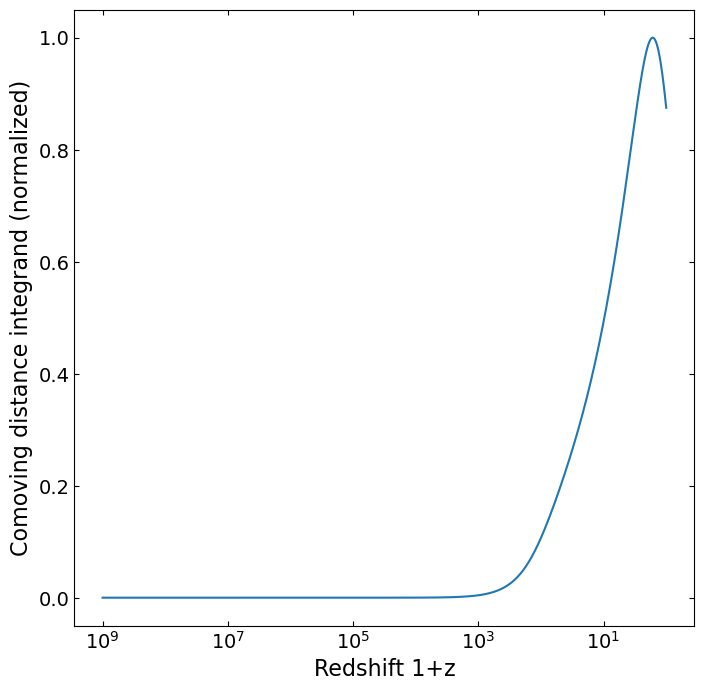

In [16]:
PLOT_chi_integrand(z_end=1e9, z_steps=1_000, p_0=3.15*Params.T_CNB, m_nu=0.05*Params.eV)

## Comoving distance vs. redshift.

Comoving distance from 0.0 to 1791.9529332851002


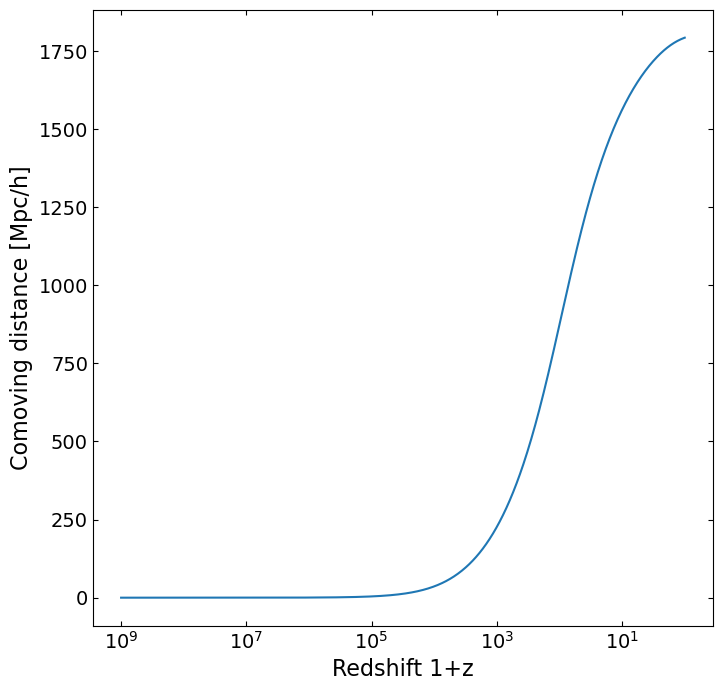

In [17]:
PLOT_chi_vs_z(z_interval=[1e9, 0], z_steps=1_000, p_0=3.15*Params.T_CNB, m_nu=0.05*Params.eV)

# Zimmer+23 neutrino vectors.

In [38]:
# Load all vectors
# vector_dir = "project_data/primordial_fluctuations/neutrino_vectors"
# substring = "halo13_batch"
# filenames = DATA_get_files_from_directory(vector_dir, substring)
# all_vectors = DATA_concatenate_npy_files(filenames)

all_vectors = SimData.load_vectors(
    sim_dir="sim_output/Dopri5_1k", halo_num=1).squeeze().reshape(-1, 2, 6)
print(all_vectors.shape)

# Specified neutrino selection
nu_mass_choice = 0.05*Params.eV
cut_vectors = UTIL_select_neutrinos_momentum_filter(
    all_vectors, nu_mass_choice)

# Split into position and velocities
Zimmer_pos = DATA_positions(cut_vectors)
Zimmer_vel = DATA_velocities(cut_vectors)


# Free up memory
del all_vectors, cut_vectors

# Distances at last simulation redshift
Zimmer_distances_zBack = UTIL_magnitudes(Zimmer_pos[:,-1,:])
print(Zimmer_distances_zBack.shape, Zimmer_pos[:,-1,:].shape)
# PLOT_3d_positions_sampled(Zimmer_pos[:,-1,:], percentage=10)

(768000, 2, 6)
628929 (81.9%) neutrinos selected.
(628929,) (628929, 3)


## Comparing distances of sim to Fermi-Dirac-no-gravity.

### At the last redshift as a 1d histogram.

In [51]:
# Generate Fermi-Dirac sampled momenta and convert to distances
z_end_sim = 4.0

Fermi_Dirac_p_samples = CALC_sample_Fermi_Dirac_momentum(
    len(Zimmer_distances_zBack), Params.T_CNB, 10*Params.T_CNB)

Fermi_Dirac_distances = np.array([
    CALC_LSS_distance(z_end_sim, p_0=p, m_nu=nu_mass_choice)/(Params.kpc/Params.h)
    for p in Fermi_Dirac_p_samples])

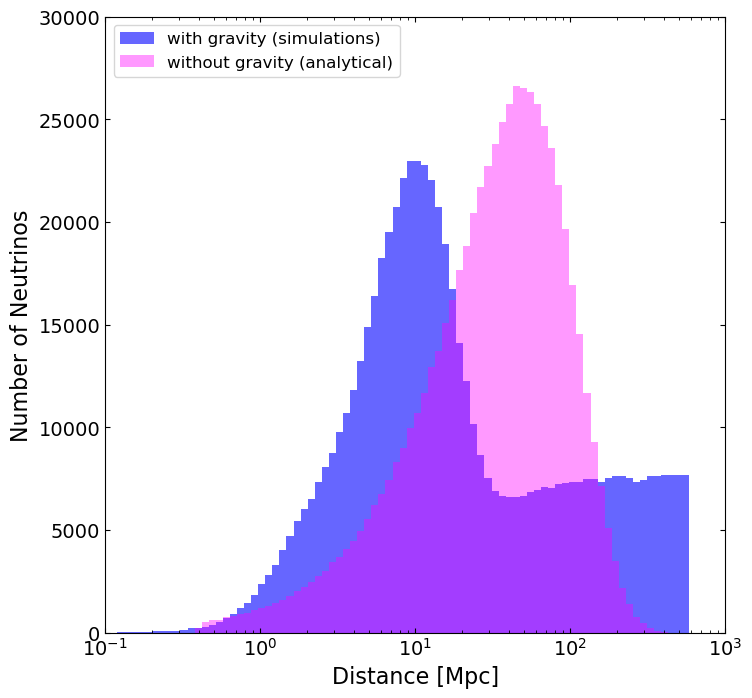

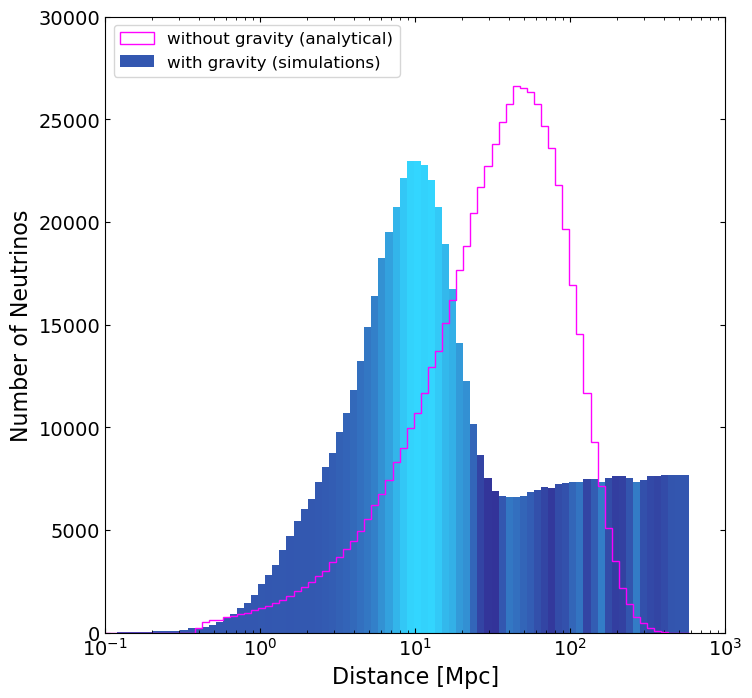

In [65]:
Fermi_Dirac_distances = np.load(f"Fermi_Dirac_distances_halo1.npy")

PLOT_distances_histogram_log_bins_abs(
    distances=Zimmer_distances_zBack, 
    Fermi_Dirac=Fermi_Dirac_distances, 
    CMB_LSS=False, 
    ax_lims=(1e-1, 1e3, 0, 30000)
)
PLOT_distances_histogram_log_bins_abs_Cgrad(
    positions=Zimmer_pos[:,-1,:], 
    Fermi_Dirac=Fermi_Dirac_distances, 
    CMB_LSS=False, 
    ax_lims=(1e-1, 1e3, 0, 30000)
)
# PLOT_distances_histogram_log_bins_perc(
#     distances=Zimmer_distances_zBack, 
#     Fermi_Dirac=Fermi_Dirac_distances, 
#     CMB_LSS=False, 
#     ax_lims=(1e-1, 1e3, 0, 5)
# )

I think what the above plot shows is that the majority of neutrino get "pulled back" w.r.t. the Fermi-Dirac no-gravity case, whereas some neutrinos actually experience a "slingshot-type" effect. The latter is that neutrinos which first travel towards the center of potential will experience a boost in velocity due to the gravitational pull, but once they have reached the other side, the potential will have diminished in that time (recall that we're simulating backwards in time) and the pull will be less strong, allowing them to escape with a larger velocity that their initial one.

### At all redshifts as a 2d histogram.

In [23]:
# Logarithmic redshift spacing (from neutrino_clustering repository)
z_int_shift = 0.1
z_int_stop = 4
z_int_num = 100
z_int_steps = np.geomspace(z_int_shift, z_int_stop+z_int_shift, z_int_num)
Zimmer_zeds = z_int_steps - z_int_shift
print(Zimmer_pos.shape)
Zimmer_distances = UTIL_magnitudes(Zimmer_pos)

PLOT_distances_2d_histogram_log_bins(Zimmer_zeds, Zimmer_distances, 'comoving')

(628929, 2, 3)


IndexError: index 2 is out of bounds for axis 1 with size 2

In [ ]:
#
#! CAUTION: this cell takes 5 min. with 4 cores

'''
# Generate Fermi-Dirac sampled momenta and convert to distances for all z
Fermi_Dirac_p_samples = CALC_sample_Fermi_Dirac_momentum(
    len(Zimmer_distances_zBack), T_CNB, 10*T_CNB)

def z_dists(z):
    return np.array([
        CALC_LSS_distance(z, p_0=p, m_nu=nu_mass_choice)/(kpc/h)
        for p in Fermi_Dirac_p_samples
    ])

# Use 4 workers for parallelization
with ProcessPoolExecutor(max_workers=4) as executor:
    Fermi_Dirac_dists_z = np.array(list(executor.map(z_dists, Zimmer_zeds)))

# Transpose to get shape (N, 100)
Fermi_Dirac_distances_zeds = Fermi_Dirac_dists_z.T


# note: Avoid division by zero, but produces unwanted horizontal line in plot?
Fermi_Dirac_distances_zeds[Fermi_Dirac_distances_zeds==0.01] = 0.0

# note: unsure why *1e6 is needed for now, bug in script when using FD values?
FD_tester = Fermi_Dirac_distances_zeds*1e6

PLOT_distances_2d_histogram_log_bins(Zimmer_zeds, FD_tester)
'''

'\n# Generate Fermi-Dirac sampled momenta and convert to distances for all z\nFermi_Dirac_p_samples = CALC_sample_Fermi_Dirac_momentum(\n    len(Zimmer_distances_zBack), T_CNB, 10*T_CNB)\n\ndef z_dists(z):\n    return np.array([\n        CALC_LSS_distance(z, p_0=p, m_nu=nu_mass_choice)/(kpc/h)\n        for p in Fermi_Dirac_p_samples\n    ])\n\n# Use 4 workers for parallelization\nwith ProcessPoolExecutor(max_workers=4) as executor:\n    Fermi_Dirac_dists_z = np.array(list(executor.map(z_dists, Zimmer_zeds)))\n\n# Transpose to get shape (N, 100)\nFermi_Dirac_distances_zeds = Fermi_Dirac_dists_z.T\n\n\n# note: Avoid division by zero, but produces unwanted horizontal line in plot?\nFermi_Dirac_distances_zeds[Fermi_Dirac_distances_zeds==0.01] = 0.0\n\n# note: unsure why *1e6 is needed for now, bug in script when using FD values?\nFD_tester = Fermi_Dirac_distances_zeds*1e6\n\nPLOT_distances_2d_histogram_log_bins(Zimmer_zeds, FD_tester)\n'

## How many neutrino reached what distance?

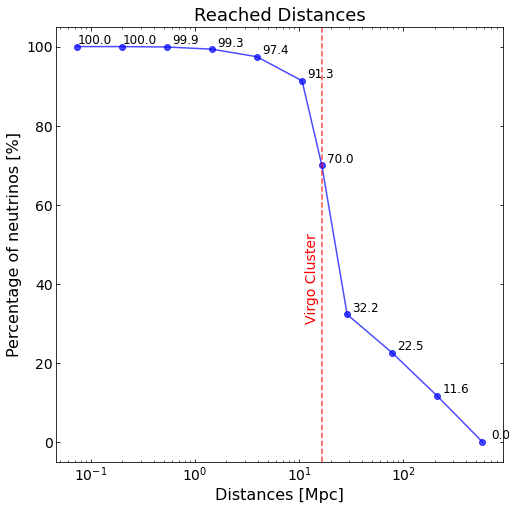

In [ ]:
PLOT_distances_percentages(Zimmer_distances_zBack)

## Distances to CNB/CMB LSS, at z_LSS (!) vs. neutrino masses.

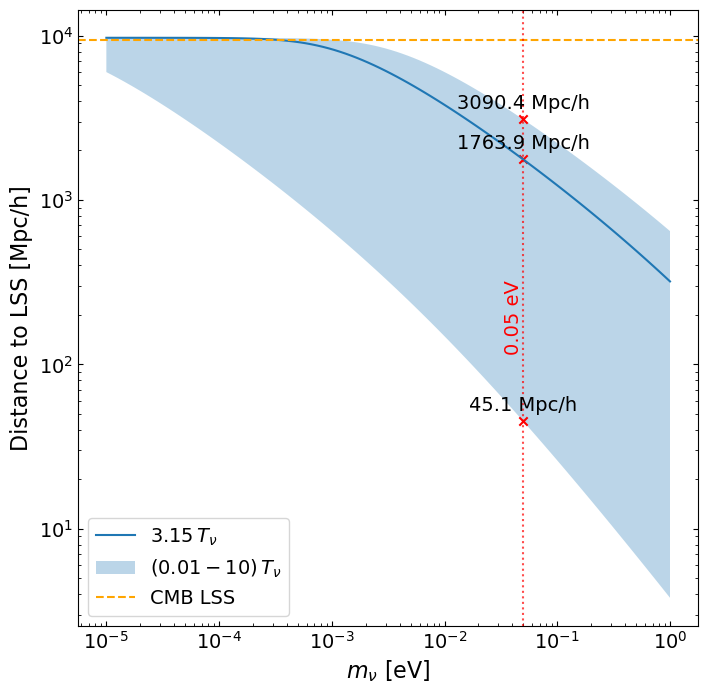

In [ ]:
PLOT_distances_to_CNB_LSS()

## Distances to CNB/CMB LSS vs. redshift (for specific neutrino mass).

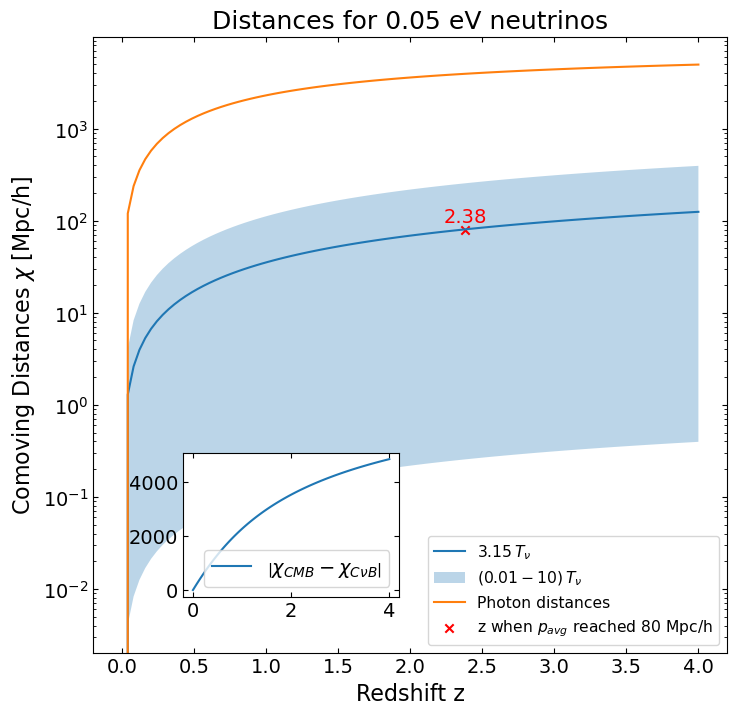

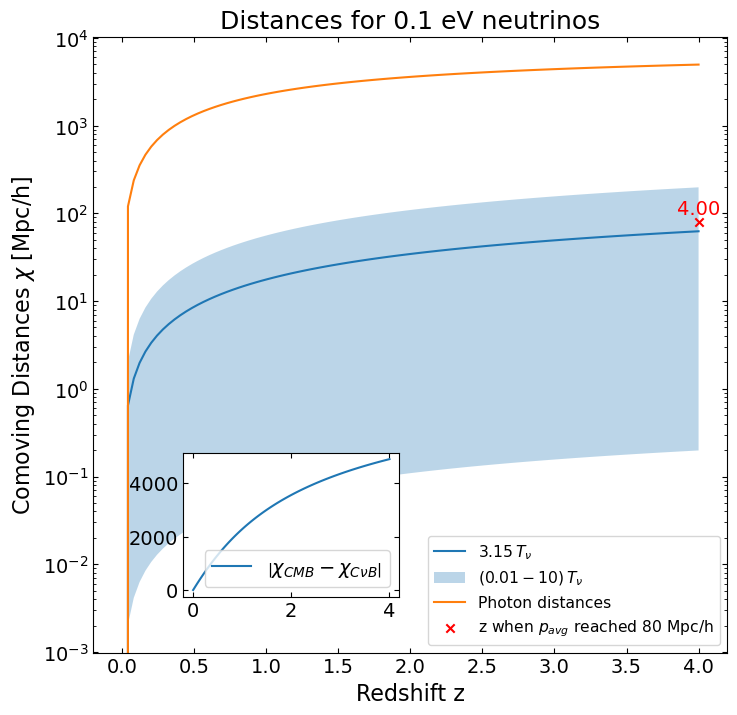

In [ ]:
z_range = np.linspace(0, 4, 100)
for m in (0.05, 0.1):
    PLOT_distances_to_CNB_LSS_redshift(z_range, m*eV, 80*(Mpc/h))
# PLOT_distances_to_CNB_LSS_redshift(z_range, 0.01*eV, 200*(Mpc/h))

#? plot versus conformal time not redshift to get vertical line for photons

# Elbers+23 neutrino vectors.

In [ ]:
def Elbers_pos_and_vel(filename):
    with h5py.File(f'{filename}', 'r') as f:
        
        # note: to inspect headers and group names of the hdf5 file
        # def print_keys(name):
        #     print(name)
        # f.visit(print_keys)

        # note: they label z0 quantities "Final" and zBack with "Initial"

        # Positions
        pos_init = np.array(f['Neutrinos/FinalCoordinates'])     # z0
        pos_final = np.array(f['Neutrinos/InitialCoordinates'])  # zBack
        pos_array = np.concatenate(
            [pos_init[:, np.newaxis, :], pos_final[:, np.newaxis, :]], axis=1
        )*Mpc

        # Center on MW (they put it in middle of box at x=y=z=500 Mpc)
        pos_array -= 500*Mpc

        # Velocities
        vel_init = np.array(f['Neutrinos/FinalVelocities'])     # z0
        vel_final = np.array(f['Neutrinos/InitialVelocities'])  # zBack
        vel_array = np.concatenate(
            [vel_init[:, np.newaxis, :], vel_final[:, np.newaxis, :]], axis=1
        )*km/s

        pos64 = np.array((pos_array/kpc), dtype=np.float64) 
        vel64 = np.array(vel_array/(kpc/s), dtype=np.float64)

        return pos64, vel64


file_path = 'project_data/primordial_fluctuations/neutrino_vectors/NUBG_MW_M150_N384_3452.hdf5'
Elbers_pos, Elbers_vel = Elbers_pos_and_vel(file_path)

## Distance Analysis.

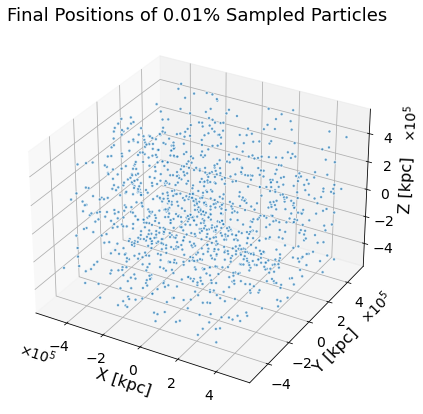

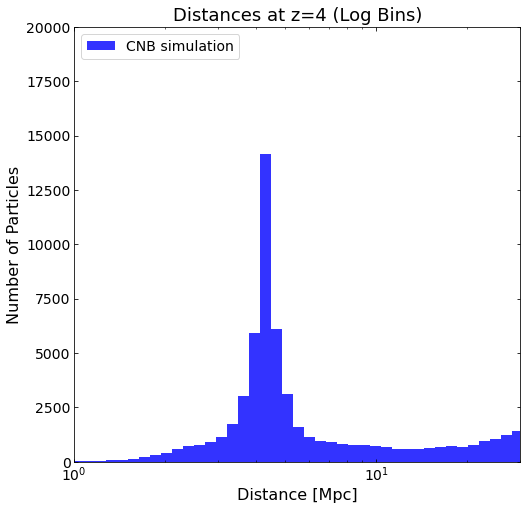

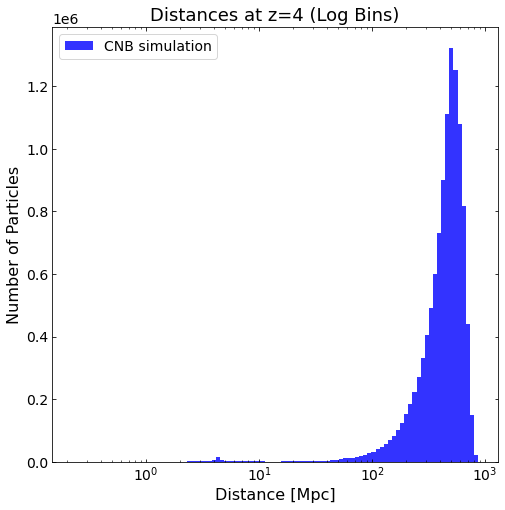

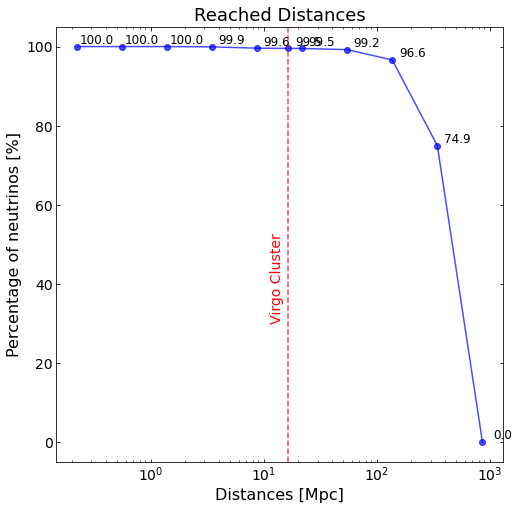

In [ ]:
# Distance Analysis of last positions
PLOT_3d_positions_sampled(Elbers_pos[:,-1,:], percentage=0.01)

PLOT_distances_histogram_log_bins(
    UTIL_magnitudes(Elbers_pos[:,-1,:]), ax_lims=[1,30,0,20000])

PLOT_distances_histogram_log_bins(
    UTIL_magnitudes(Elbers_pos[:,-1,:]))

PLOT_distances_percentages(
    UTIL_magnitudes(Elbers_pos[:,-1,:]))

## Velocity Analysis.

### Comparison of Elbers initial velocity distribution to Fermi Dirac.

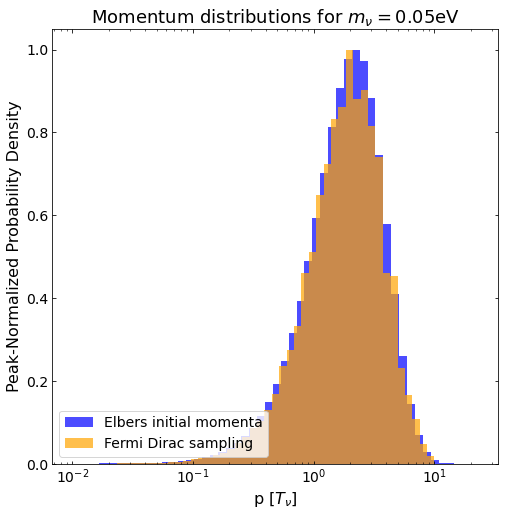

In [ ]:
def PLOT_momentum_histogram(momenta, Fermi_Dirac=False):
    # Compute magnitudes of velocity vectors
    mags = np.linalg.norm(momenta, axis=-1)
    
    # Define logarithmic bins
    log_bins = np.logspace(np.log10(np.min(mags)), np.log10(np.max(mags)), 50)

    # Calculate histogram values for first dataset
    hist_vals, bin_edges = np.histogram(mags, bins=log_bins, density=True)
    
    # Normalize peak to 1 for first dataset
    hist_vals = hist_vals / np.max(hist_vals)

    # Plot histogram
    fig = plt.figure()
    ax = fig.add_subplot(111)

    # Plotting the histogram using plt.bar for more control
    ax.bar(bin_edges[:-1], hist_vals, width=np.diff(bin_edges), align='edge', 
           alpha=0.7, color='blue', label='Elbers initial momenta')


    if Fermi_Dirac:
        # Momentum samples in units of T_CNB
        samples = CALC_sample_Fermi_Dirac_momentum(
            10_000, T_CNB, 10*T_CNB)/T_CNB

        # Logarithmic bins
        log_bins_FD = np.logspace(np.log10(0.01), np.log10(10), 50)

        # Calculate histogram values for second dataset
        hist_vals_fd, bin_edges_fd = np.histogram(samples, bins=log_bins_FD, density=True)
        
        hist_vals_fd *= bin_edges_fd[:-1]**2

        # Normalize peak to 1 for second dataset
        hist_vals_fd = hist_vals_fd / np.max(hist_vals_fd)
        
        # Plotting to verify
        ax.bar(bin_edges_fd[:-1], hist_vals_fd, 
               width=np.diff(bin_edges_fd), align='edge', 
               alpha=0.7, color='orange', label='Fermi Dirac sampling')

    ax.set_title(r'Momentum distributions for $m_\nu=0.05$eV')
    ax.legend(loc='lower left')
    ax.set_xscale('log')
    ax.set_xlabel(r'p [$T_\nu$]')
    ax.set_ylabel('Peak-Normalized Probability Density')
    
    plt.show()
    plt.close()


Elbers_nu_mass = 0.05*eV
Elbers_mom = Elbers_vel[:,0,:]*(kpc/s)*Elbers_nu_mass/T_CNB
PLOT_momentum_histogram(Elbers_mom, Fermi_Dirac=True)

In [ ]:
# Goal: plot how momentum distirbution of relic neutrinos today changes w.r.t.
# standard case, due to grav. clustering.

# Process: Sample from f_today for different masses from our simulation data.

def PLOT_momentum_today(p_nu_vals, f_today_vals):

    # Interpolate f_today
    f_interpolated = interp1d(p_nu_vals, f_today_vals, kind='cubic')

    # Generate a logarithmic grid for p_nu for a smooth CDF
    p_nu_fine = np.logspace(np.log10(p_nu_vals.min()), np.log10(p_nu_vals.max()), 1000)
    f_today_fine = f_interpolated(p_nu_fine)

    # Normalize the distribution to get a PDF
    pdf = f_today_fine / np.trapz(f_today_fine, p_nu_fine)

    # Compute the CDF
    cdf = np.cumsum(pdf)
    cdf /= cdf[-1]  # Normalize to make it a proper CDF

    # Inverse sampling function
    def inverse_sample(n_samples):
        # Generate uniform random numbers
        rand_uniform = np.random.rand(n_samples)
        
        # Find corresponding p_nu values using np.searchsorted
        sampled_indices = np.searchsorted(cdf, rand_uniform)
        sampled_p_nu = p_nu_fine[sampled_indices]

        return sampled_p_nu

    # Example usage
    n_samples = 1000
    sampled_momenta = inverse_sample(n_samples)

    # Plotting the sampled momenta as a histogram
    plt.hist(sampled_momenta, bins=50, density=True, alpha=0.7, label='Sampled Data')
    plt.plot(p_nu_fine, pdf, label='PDF', color='red')
    plt.xlabel('Momentum $p_\\nu$')
    plt.ylabel('Probability Density')
    plt.title('Inverse Sampling from $f_{today}(p_\\nu)$')
    plt.legend()
    plt.show()


# Generate PTOLEMY electron spectra, using these momentum distributions.